# **Interactive Fossil Map**

This is the map of the distribution of fossils across the world. Play around with it and view each kind of dinosaur and their info

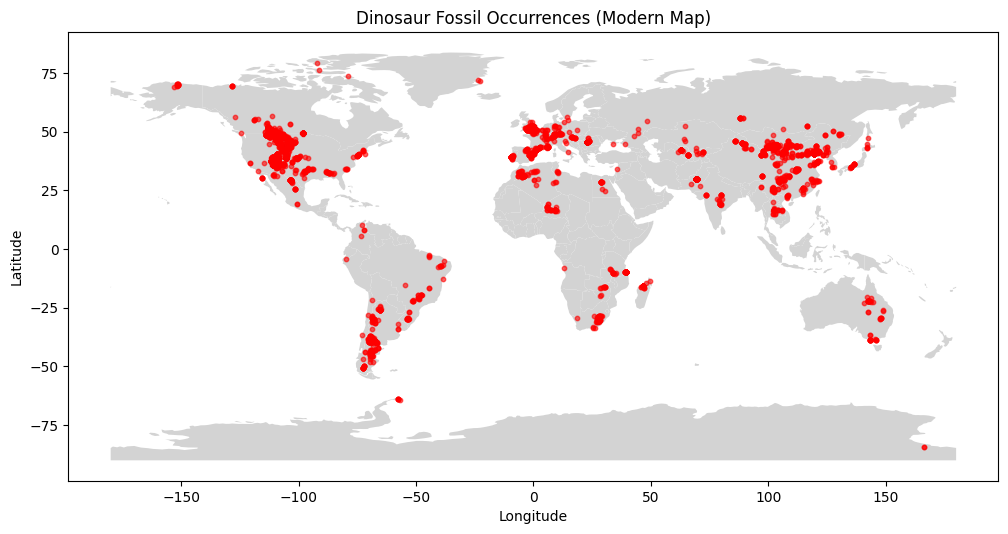

In [3]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt
import folium as fm
import requests as rq
import io

%run dino_visualization.ipynb

In [5]:
map = fm.Map(location=[20, 0], 
             zoom_start=1.75, 
             max_bounds=True,
             min_lat=-90,
             max_lat=90,
             min_lon=-180,
             max_lon=180)

marker_colors = ['red', 'green', 'blue']

for index, i in occ.iterrows():
   
    
    perd = i['Early Period']
    if (i['Early Period'] != i['Late Period']):
        perd += ' - ' + i['Late Period']
    
    diet = str(i['Diet'])
    mc = 'red' if diet == 'Carnivore' else ('green' if diet == 'Herbivore' else 'black' if diet == 'nan' else 'blue')
    
    marker_desc = '<h3><b><i>' + i['Species'] + '</i></b></h3><br><b>Diet:</b> ' + diet + '<br><b>Period:</b> ' + perd + '<br><b>Formation:</b> ' + str(i['Formation']) + '<br><b>Country:</b> ' + str(i['Country']) + '<br><b>State:</b> ' + str(i['State']) +'<br><b>Coordinates:</b> (' + str(i['Latitude']) + ', ' + str(i['Longitude']) + ')'
    pop = fm.IFrame(marker_desc)
    fm.CircleMarker(location=[i['Latitude'], i['Longitude']],
                    radius=5, popup=fm.Popup(pop, min_width = 250, max_width = 250),
                    color=mc).add_to(map)

map